# NB02e — Plan-Based Audit and Prune

> Copyright (C) 2024-2026 Marco Heinzen - SPDX-License-Identifier: AGPL-3.0-or-later
> Part of the Master Thesis "Building Damage Assessment with Multimodal Satellite Time Series and Machine Learning in the Russia-Ukraine War 2022-2026"
> Code hosted at https://github.com/marcoheinzen/bda
> Parts of this code were written or improved with the assistance of Claude (Anthropic); all other code, and the concept, research, architecture, design, execution, testing and validation throughout, are the author's work.



| Field | Value |
|-------|-------|
| **Notebook** | `02e_bda_Sync_Audit_Prune_v12.ipynb` |
| **Version** | v12 |
| **Pipeline position** | Maintenance utility. After NB02b/c/d (downloads), before NB03 (processing). |
| **Last validated** | 2026-04-XX |

## Narrative

Standalone maintenance notebook that audits and optionally prunes downloaded zip
archives using `nb02a_scene_plan.json` as single source of truth. No downloads —
only inventory, comparison, and cleanup.

**Pruning is currently deferred.** Re-downloading is the primary bottleneck:
SLC ~8 GB at ~5 Mbit/s ESA bandwidth (~3.5h per scene), CARD ~4 GB, MS ~1 GB.
All zips are kept to avoid re-acquisition if tier assignments or plans change.

The notebook provides four operations:
1. **PLAN-INVENTORY** — compare plan expectations vs actual zips on disk (matched/missing/orphan)
2. **PLAN-DL-STATUS** — scenes still needing download per modality
3. **DL-AUDIT-ZIPS** — cross-reference zips against trackers and size thresholds
4. **DL-PRUNE-ZIPS** — delete orphan zips not in plan/metadata (DRY_RUN=True default)
5. **DL-RECONCILE** — fix tracker status drift vs disk reality
6. **DL-SQLITE** — sync all results to bda.sqlite catalog

## Scientific Rationale
Data provenance and storage hygiene are required for reproducibility. The audit
trail documents which scenes are on disk, which the plan expects, and which are
orphaned. This supports the thesis methodology section demonstrating processing
was performed on a controlled, documented dataset.

## Inputs

| Data | Source | Format |
|------|--------|--------|
| `nb02a_scene_plan.json` | NB02a | JSON (single source of truth) |
| SLC zips | `RAW_SLC_ZIP/` (NB02d) | ~4-8 GB each |
| CARD zips | `CARD_ZIP_DIR/` (NB02c) | ~2-4 GB each |
| MS zips | `MS_ZIP_DIR/` (NB02b) | ~0.5-1 GB each |
| Processing trackers | NB03a/b | JSON per city |

## Outputs

| Artifact | Path | Used by |
|----------|------|---------|
| Audit report (in-notebook) | — | Operator review |
| Fixed trackers (if FIX_MODE) | Various tracker JSONs | NB03a/b |
| Pruned zips (if DRY_RUN=False) | Deleted from zip dirs | Disk reclamation |
| `bda.sqlite` (zip_catalog tables) | `CATALOG_DB` | NB05, audit trail |

## Prerequisites
- NB02a must have run (plan exists)
- NB02b/c/d should have run (zips on disk to audit)

## Key Methodological Choices

| Choice | Justification | Reference |
|--------|---------------|-----------|
| Plan as single source of truth | v12 refactor: no legacy tracker-based logic | Architecture principle |
| DRY_RUN_PRUNE=True default | Prevent accidental deletion of expensive downloads | Safety |
| PRUNE_SELECTORS=["wrong_tile","date_excess"] | Only prune definitively wrong files | Conservative |
| MIN_SLC_SIZE=3GB, MIN_CARD_SIZE=1GB | Reject truncated downloads | Empirical |
| FIX_MODE + BACKUP_BEFORE_FIX | Auto-fix tracker drift with rollback | Robustness |

## Python Modules

| Module | Cell | What |
|--------|------|------|
| `dl_audit_zips.py` | DL-AUDIT-ZIPS | Zip inventory vs tracker cross-ref |
| `dl_prune_zips.py` | DL-PRUNE-ZIPS | Metadata-based zip pruning |
| `dl_reconcile.py` | DL-RECONCILE | Tracker status reconciliation |
| `zip_catalog.py` | DL-SQLITE | Sync results to bda.sqlite |

## Cell Structure

| Cell | ID | What | Status |
|------|----|------|--------|
| 0 | — | Documentation (this cell) | — |
| 1-2 | Cell 3 | Config (DRY_RUN_PRUNE, FIX_MODE, size thresholds) | Config |
| 3-4 | Cell 4 | Load global_setup | Config |
| 5-6 | LOAD-PLAN | Load plan + filter by tier | **Core** |
| 7-8 | PLAN-INVENTORY | Plan expected vs zips on disk (matched/missing/orphan) | **Core** |
| 9-10 | PLAN-DL-STATUS | Scenes still needing download per modality | Diagnostic |
| 11-12 | DL-AUDIT-ZIPS | Zip inventory vs tracker status | **Core** |
| 13-14 | DL-PRUNE-ZIPS | Prune orphan zips (DRY_RUN default) | Optional |
| 15-16 | DL-RECONCILE | Fix tracker inconsistencies | **Core** |
| 17-18 | DL-SQLITE | Sync audit + prune to bda.sqlite | **Core** |
| 19-20 | SUMMARY | Completion report | QA |

## Thesis Mapping

| Thesis Section | Cells | Content |
|----------------|-------|---------|
| 3.3 Preprocessing — Data Management | DL-AUDIT, PLAN-INVENTORY | Audit trail, provenance |
| Appendix — Data Inventory | PLAN-INVENTORY, PLAN-DL-STATUS | Scene counts per modality |

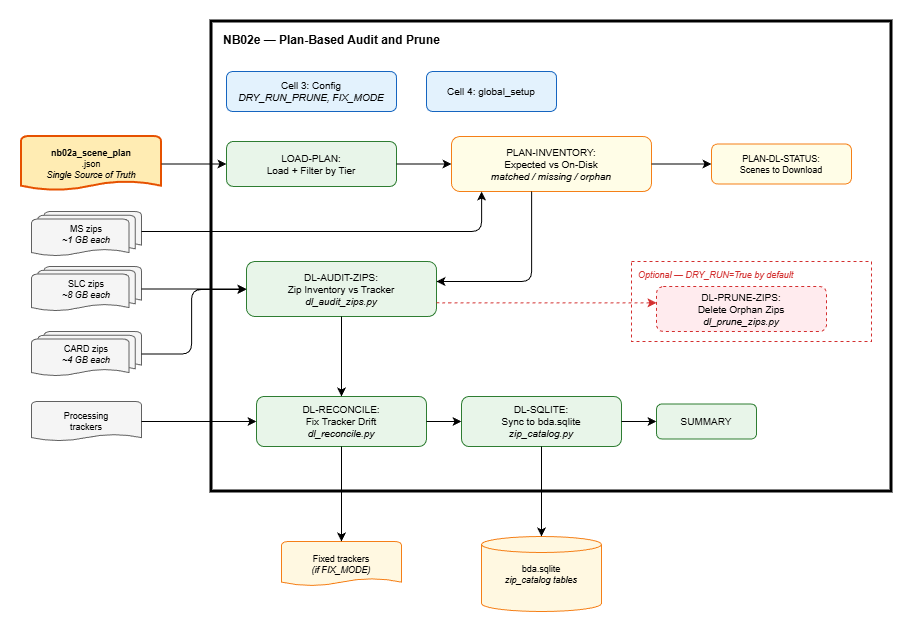

# NB02e CONFIG

In [ ]:
# @title CELL 3: NB02e CONFIG
TIER_SELECTION = [0, 1, 2, 3, 4, 5]
CITY_SELECTION = None

# prune config
DRY_RUN_PRUNE = True             # True = report only, False = delete
FIX_MODE = True                  # reconciler fixes trackers
BACKUP_BEFORE_FIX = True

# zip size thresholds
MIN_SLC_SIZE = 3e9               # 3GB minimum valid SLC zip
MIN_CARD_SIZE = 1e9              # 1GB minimum valid CARD zip


# LOAD GLOBAL SETUP

In [ ]:
# @title CELL 4: LOAD GLOBAL SETUP
import platform, os
if platform.system() == 'Windows':
    _setup = r'F:\\PROJECTS\\masterthesis\\gdrive\\masterthesis\\notebooks\\global_setup.py'
elif os.path.exists('/content/drive_f'):
    _setup = '/content/drive_f/masterthesis/notebooks/global_setup.py'
else:
    _setup = '/mnt/f/PROJECTS/masterthesis/gdrive/masterthesis/notebooks/global_setup.py'
with open(_setup) as f:
    exec(f.read())


# LOAD NB02a SCENE PLAN

In [ ]:
# @title CELL LOAD-PLAN: Load nb02a_scene_plan.json
import json
from pathlib import Path

PLAN_FILE = OUTPUTS_DIR / 'nb02a_scene_plan.json'
assert PLAN_FILE.exists(), f'Plan file not found: {PLAN_FILE}'

with open(PLAN_FILE) as f:
    PLAN = json.load(f)

print(f'Plan loaded: {len(PLAN)} cities from {PLAN_FILE.name}')
print(f'Plan file size: {PLAN_FILE.stat().st_size / 1024:.1f} KB')

# filter by tier
plan_cities = {}
for city, data in PLAN.items():
    tier = data.get('tier')
    if CITY_SELECTION:
        if city in (CITY_SELECTION if isinstance(CITY_SELECTION, list) else [CITY_SELECTION]):
            plan_cities[city] = data
    elif tier is not None and tier in TIER_SELECTION:
        plan_cities[city] = data

print(f'Filtered: {len(plan_cities)} cities (tiers={TIER_SELECTION})')
for city, data in sorted(plan_cities.items()):
    counts = data.get('counts', {})
    print(f'  {city:25s} T{data.get("tier","?")}  '
          f'SLC={counts.get("slc_on_disk",0)}/{counts.get("slc_total",0)}  '
          f'CARD={counts.get("card_on_disk",0)}/{counts.get("card_total",0)}  '
          f'MS={counts.get("ms_on_disk",0)}/{counts.get("ms_total",0)}')


# PLAN INVENTORY: Expected vs On-Disk

In [ ]:
# @title CELL PLAN-INVENTORY: Compare plan expectations vs actual zips on disk
import os, re
from collections import defaultdict

def scan_zips(zip_dir, pattern=None):
    """Return set of zip filenames in a directory."""
    found = set()
    if not zip_dir.exists():
        return found
    for f in zip_dir.iterdir():
        if f.suffix == '.zip':
            found.add(f.name)
    return found

slc_zips_on_disk = scan_zips(RAW_SLC_ZIP)
card_zips_on_disk = scan_zips(CARD_ZIP_DIR)
ms_zips_on_disk = scan_zips(MS_ZIP_DIR)

print(f'Zips on disk: SLC={len(slc_zips_on_disk)}, CARD={len(card_zips_on_disk)}, MS={len(ms_zips_on_disk)}')
print()

# build expected scene_name sets from plan
plan_slc_expected = set()
plan_card_expected = set()
plan_ms_expected = set()

for city, data in plan_cities.items():
    for scene in data.get('slc', []):
        if scene.get('status') == 'on_disk':
            plan_slc_expected.add(scene['scene_name'])
    for scene in data.get('card', []):
        if scene.get('status') == 'on_disk':
            plan_card_expected.add(scene['scene_name'])
    for scene in data.get('ms', []):
        if scene.get('status') == 'on_disk':
            plan_ms_expected.add(scene['scene_name'])

print(f'Plan expects on_disk: SLC={len(plan_slc_expected)}, CARD={len(plan_card_expected)}, MS={len(plan_ms_expected)}')
print()

# cross-reference: plan scene_names vs zip filenames
# SLC zips contain scene_name in filename
def match_zips_to_scenes(zips_on_disk, expected_scene_names, modality):
    matched = set()
    unmatched_zips = set()
    for zf in zips_on_disk:
        found = False
        for sn in expected_scene_names:
            if sn in zf or zf.replace('.zip', '') in sn:
                matched.add(sn)
                found = True
                break
        if not found:
            unmatched_zips.add(zf)
    missing = expected_scene_names - matched
    return matched, missing, unmatched_zips

for modality, zips, expected in [
    ('SLC', slc_zips_on_disk, plan_slc_expected),
    ('CARD', card_zips_on_disk, plan_card_expected),
    ('MS', ms_zips_on_disk, plan_ms_expected),
]:
    matched, missing, orphan_zips = match_zips_to_scenes(zips, expected, modality)
    print(f'{modality}: {len(matched)}/{len(expected)} matched, {len(missing)} missing, {len(orphan_zips)} orphan zips')
    if missing and len(missing) <= 20:
        for m in sorted(missing):
            print(f'  MISSING: {m}')
    elif missing:
        print(f'  {len(missing)} missing scenes (too many to list)')
    if orphan_zips and len(orphan_zips) <= 20:
        for o in sorted(orphan_zips):
            print(f'  ORPHAN:  {o}')
    elif orphan_zips:
        print(f'  {len(orphan_zips)} orphan zips not in plan (too many to list)')
    print()


# PLAN DOWNLOAD STATUS

In [ ]:
# @title CELL PLAN-DL-STATUS: Scenes still needing download per plan
from collections import Counter

for modality in ['slc', 'card', 'ms']:
    status_counts = Counter()
    to_download = []
    for city, data in plan_cities.items():
        for scene in data.get(modality, []):
            status_counts[scene.get('status', 'unknown')] += 1
            if scene.get('status') == 'to_download':
                to_download.append((city, scene['date'], scene['scene_name']))
    print(f'{modality.upper()}: {dict(status_counts)}')
    if to_download and len(to_download) <= 30:
        for city, date, sn in sorted(to_download):
            print(f'  to_download: {city:25s} {date} {sn[:60]}')
    elif to_download:
        print(f'  {len(to_download)} scenes to download (too many to list)')
    print()


# CELL DL-AUDIT-ZIPS: ZIP INVENTORY + TRACKER STATUS

In [ ]:
# @title CELL DL-AUDIT-ZIPS: ZIP INVENTORY + TRACKER STATUS
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import dl_audit_zips
importlib.reload(dl_audit_zips)
from dl_audit_zips import run as run_audit_zips

NB02_AUDIT = run_audit_zips(
    raw_slc_zip=RAW_SLC_ZIP,
    card_zip_dir=CARD_ZIP_DIR,
    ms_zip_dir=MS_ZIP_DIR,
    orbits_dir=ORBITS_DIR,
    outputs_dir=OUTPUTS_DIR,
    insar_tracker_file=INSAR_TRACKER_FILE,
    card_tracker_file=CARD_TRACKER_FILE,
    min_slc_size=MIN_SLC_SIZE,
)


# CELL DL-PRUNE-ZIPS: ZIP PRUNING (PLAN-BASED)

In [ ]:
# @title CELL DL-PRUNE-ZIPS: ZIP PRUNING (METADATA-BASED, ALL CITIES)
# No tier filtering. No scene selector. Protection from discovery metadata + tracker.
import dl_prune_zips
importlib.reload(dl_prune_zips)
from dl_prune_zips import run as run_prune_zips

DRY_RUN_PRUNE = False
PRUNE_SELECTORS=["wrong_tile", "date_excess"]

PRUNE_RESULTS = run_prune_zips(
    raw_slc_zip=RAW_SLC_ZIP,
    card_zip_dir=CARD_ZIP_DIR,
    ms_zip_dir=MS_ZIP_DIR,
    sar_metadata_dir=SAR_METADATA_DIR,
    ms_metadata_dir=MS_METADATA_DIR,
    cities_dir=CITIES_DIR,
    card_tracker_file=CARD_TRACKER_FILE,
    insar_tracker_file=INSAR_TRACKER_FILE,
    nb02_audit=NB02_AUDIT if 'NB02_AUDIT' in dir() else None,
    dry_run=DRY_RUN_PRUNE,
    min_slc_size=MIN_SLC_SIZE,
    prune_selector=PRUNE_SELECTORS,
)


# CELL DL-RECONCILE: TRACKER RECONCILER

In [ ]:
# @title CELL DL-RECONCILE: TRACKER RECONCILER
import dl_reconcile
importlib.reload(dl_reconcile)
from dl_reconcile import run as run_dl_reconcile

RECONCILE_RESULTS = run_dl_reconcile(
    raw_slc_zip=RAW_SLC_ZIP,
    sar_card_dir=SAR_CARD_DIR,
    ms_zip_dir=MS_ZIP_DIR,
    outputs_dir=OUTPUTS_DIR,
    insar_tracker_file=INSAR_TRACKER_FILE,
    card_tracker_file=CARD_TRACKER_FILE,
    nb02_audit=NB02_AUDIT if 'NB02_AUDIT' in dir() else None,
    fix_mode=FIX_MODE,
    backup_before_fix=BACKUP_BEFORE_FIX,
)


# CELL DL-SQLITE: SYNC AUDIT+PRUNE TO bda.sqlite

In [ ]:
# @title CELL DL-SQLITE: SYNC AUDIT+PRUNE TO bda.sqlite
import sys, importlib
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

import zip_catalog
importlib.reload(zip_catalog)
from zip_catalog import sync_audit_to_sqlite, sync_prune_to_sqlite, summary as zip_summary

print(f'CATALOG_DB: {CATALOG_DB}')
print(f'  exists: {CATALOG_DB.exists()}')

if 'NB02_AUDIT' in dir() and NB02_AUDIT is not None:
    sync_audit_to_sqlite(CATALOG_DB, NB02_AUDIT)
else:
    print('  NB02_AUDIT not available, skipping audit sync')

if 'PRUNE_RESULTS' in dir() and PRUNE_RESULTS is not None:
    sync_prune_to_sqlite(CATALOG_DB, PRUNE_RESULTS, dry_run=globals().get('DRY_RUN_PRUNE', True))
else:
    print('  PRUNE_RESULTS not available, skipping prune sync')

import sqlite3
_conn = sqlite3.connect(str(CATALOG_DB))
_tables = [r[0] for r in _conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
_conn.close()
print(f'  tables: {_tables}')

zip_summary(CATALOG_DB)


# SUMMARY

In [ ]:
# @title SUMMARY
print('=' * 80)
print('NB02e COMPLETE')
print('=' * 80)
print(f'  Plan: {len(plan_cities)} cities from {PLAN_FILE.name}')
for vname in ['NB02_AUDIT', 'RECONCILE_RESULTS', 'PRUNE_RESULTS']:
    obj = globals().get(vname)
    if obj is not None and isinstance(obj, dict):
        print(f'  {vname:20s} keys: {list(obj.keys())}')
    else:
        print(f'  {vname:20s} (not run)')
if globals().get('CATALOG_DB') and Path(CATALOG_DB).exists():
    print(f'  CATALOG_DB: {CATALOG_DB} ({Path(CATALOG_DB).stat().st_size / 1024:.1f} KB)')
if globals().get('DRY_RUN_PRUNE', False):
    print(f'\n  DRY_RUN_PRUNE=True -> nothing deleted')
    print(f'  Set DRY_RUN_PRUNE=False in Cell 3 and rerun prune cell to execute')
